<a href="https://colab.research.google.com/github/prachitshukla/Team-2/blob/music_sentiment_analysis/M5_Mini_Hackathon_Classification_of_Emotions_of_Musical_Audio_Files_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Objective:

To classify Happy or Sad Emotions in Musical Audio Files using deep learning techniques. Essentially, it is a binary classification framework.

### Problem Statement

To build/develop and implement a deep learning model for the classification of emotional tones between Happy or Sad Emotions in Musical Audio Files dataset.

At the end of this competition, you will be able to:

Load and extract audio features from wave files in the Musical Audio Files dataset using librosa, encompassing MFCC (Mel-Frequency Cepstral Coefficients), Mel spectrogram, and STFT (Short-time Fourier Transform).

Develop a deep learning model utilizing either the Keras or PyTorch deep learning libraries.


### Description:

Dataset Description: The original dataset contains 7 classes but this is just a subset of the original dataset which contains 2 classes. The audio files in the dataset were already preprocessed by converting them into smaller chunks of equal size. All music were divided into 10 seconds smaller chunks using FFMPEG.

The chunks of the same song have the equally spaced names like : Happy20001-Happy20016(Same song) The last two digits resembles the chunk number while the first three digits are the ID of the original song which is provided as the GroupID. The two classes are: 1.)Happy and 2.)Sad


## Grading = 10 Marks

Here is a handy link to Kaggle's competition documentation (https://www.kaggle.com/docs/competitions), which includes, among other things, instructions on submitting predictions (https://www.kaggle.com/docs/competitions#making-a-submission).

### Instructions for downloading train and test data are as follows:

### 1. Create an API key in Kaggle.

To do this, go to the competition site on Kaggle at (https://www.kaggle.com/t/058bf9c00aeb4e30967d10d11e2441ae) and click on user then click on your profile as shown below. Click Account.

![alt text](https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Capture-NLP.PNG)

### 2. Next, scroll down to the API access section and click on **Create New Token** to download an API key (kaggle.json).

![alt text](https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Capture-NLP_1.PNG)

### 3. Upload your kaggle.json file using the following snippet in a code cell:



In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kiansh21","key":"224b5347a022995a7f669f23b2dad684"}'}

In [ ]:
#If successfully uploaded in the above step, the 'ls' command here should display the kaggle.json file.
%ls

kaggle.json  sample_data/


### 4. Install the Kaggle API using the following command


In [ ]:
!pip install -U -q kaggle==1.5.8

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2024.12.1 requires urllib3>=1.26.5, but you have urllib3 1.24.3 which is incompatible.
torchdata 0.11.0 requires urllib3>=1.25, but you have urllib3 1.24.3 which is incompatible.
sentry-sdk 2.29.1 requires urllib3>=1.26.11, but you have urllib3 1.24.3 which is incompatible.
blobfile 3.0.0 requires urllib3<3,>=1.25.3, but you have urllib3 1.24.3 which is incompatible.


### 5. Move the kaggle.json file into ~/.kaggle, which is where the API client expects your token to be located:



In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
#Execute the following command to verify whether the kaggle.json is stored in the appropriate location: ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!chmod 600 /root/.kaggle/kaggle.json #run this command to ensure your Kaggle API token is secure on colab

### 6. Now download the Test Data from Kaggle

**NOTE: If you get a '403 - Not Found' error after running the cell below, it is most likely that the user (whose kaggle.json is uploaded above) has not 'accepted' the rules of the competition and therefore has 'not joined' the competition.**

If you encounter **401-unauthorised** download latest **kaggle.json** by repeating steps 1 & 2

In [ ]:
#If you get a forbidden link, you have most likely not joined the competition.
!kaggle competitions download -c classification-of-emotions-of-musical-audio-files
!unzip classification-of-emotions-of-musical-audio-files.zip

 98% 626M/641M [00:04<00:00, 192MB/s]
100% 641M/641M [00:04<00:00, 143MB/s]
Archive:  classification-of-emotions-of-musical-audio-files.zip
  inflating: Test/Test/1.wav         
  inflating: Test/Test/10.wav        
  inflating: Test/Test/100.wav       
  inflating: Test/Test/101.wav       
  inflating: Test/Test/102.wav       
  inflating: Test/Test/103.wav       
  inflating: Test/Test/104.wav       
  inflating: Test/Test/105.wav       
  inflating: Test/Test/106.wav       
  inflating: Test/Test/107.wav       
  inflating: Test/Test/108.wav       
  inflating: Test/Test/109.wav       
  inflating: Test/Test/11.wav        
  inflating: Test/Test/110.wav       
  inflating: Test/Test/111.wav       
  inflating: Test/Test/112.wav       
  inflating: Test/Test/113.wav       
  inflating: Test/Test/114.wav       
  inflating: Test/Test/115.wav       
  inflating: Test/Test/116.wav       
  inflating: Test/Test/117.wav       
  inflating: Test/Test/118.wav       
  inflating: Test/Test/1

### YOUR CODING STARTS FROM HERE

### Import Neccesary Packages

In [ ]:
# YOUR CODE HERE
! pip install librosa

In [ ]:
import torch
import os
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import librosa
import librosa.display
from pathlib import Path
from matplotlib import pyplot as plt
import torch.nn.functional as F


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


import random


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from transformers import AutoProcessor, AutoModelForAudioClassification
import torchaudio

from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


### **Stage 1:** Load the Train data audio files (1 point)




In [ ]:
#Load from Train Set
data_path = './Train/Train'

def get_files(path, extension='.wav'):
    return list(path.rglob(f'*{extension}'))


label_id = {"01": "happy",
            '02': "sad"
           }

# Get all files from the ravdess data folders
all_files = get_files(Path(data_path))
print(len(all_files))




1873


#### Play the sample audio

In [ ]:
import IPython.display as ipd
ipd.Audio(filename=os.path.join(os.getcwd(), all_files[1872]), rate=48000)

### **Stage 2:** Data Exploration and Visualization (1 point)


*  Find count of each label and plot bar graph



<class 'list'>
1873
{'file': PosixPath('Train/Train/Sad/Sad31704.wav'), 'label': 'sad'}


<Axes: xlabel='label', ylabel='count'>

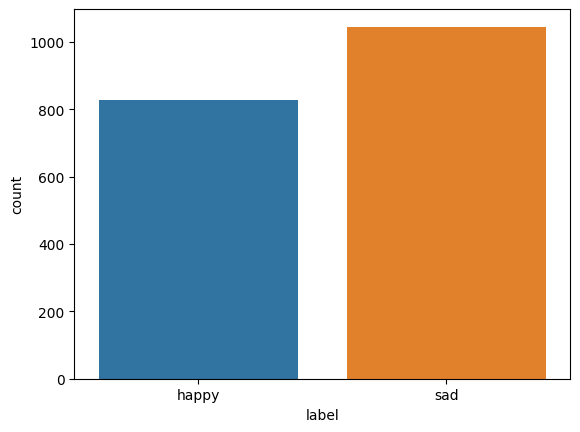

In [ ]:
# YOUR CODE HERE
labels = list(map(lambda f: {"file": f, "label": "happy" if "happy" in os.path.basename(f).lower() else "sad"}, all_files))
print(type(labels))
print(len(labels))
print(labels[1872])


df_labels = pd.DataFrame(labels)
df_labels.head()
df_labels.tail()

sns.countplot(data=df_labels, x="label", hue='label')
#plt.show()


#### Visualize sample audio signal using librosa

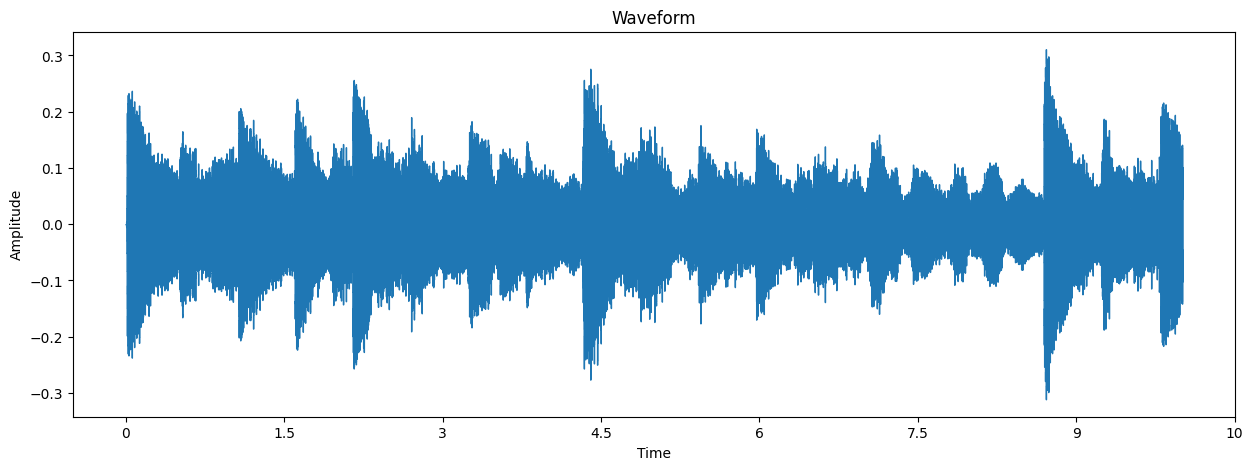

In [ ]:
# YOUR CODE HERE
sample_audio_path = os.path.join(os.getcwd(), all_files[1872])

# librosa is used for analyzing and extracting features of an audio signal
data, sampling_rate = librosa.load(sample_audio_path)
plt.figure(figsize=(15, 5))


# librosa.display.waveshow is used to plot waveform of amplitude vs time
librosa.display.waveshow(data, sr=sampling_rate)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Waveform")
plt.show()

### **Stage 3:** Feature extraction (2 points)


In [ ]:
#suffle array values
print(all_files)
random.shuffle(all_files)
print('*'.center(80,'*'))
print(all_files)

[PosixPath('Train/Train/Happy/Happy19711.wav'), PosixPath('Train/Train/Happy/Happy10206.wav'), PosixPath('Train/Train/Happy/Happy14004.wav'), PosixPath('Train/Train/Happy/Happy14414.wav'), PosixPath('Train/Train/Happy/Happy25602.wav'), PosixPath('Train/Train/Happy/Happy39110.wav'), PosixPath('Train/Train/Happy/Happy13510.wav'), PosixPath('Train/Train/Happy/Happy19917.wav'), PosixPath('Train/Train/Happy/Happy22010.wav'), PosixPath('Train/Train/Happy/Happy19912.wav'), PosixPath('Train/Train/Happy/Happy29900.wav'), PosixPath('Train/Train/Happy/Happy13200.wav'), PosixPath('Train/Train/Happy/Happy37402.wav'), PosixPath('Train/Train/Happy/Happy17819.wav'), PosixPath('Train/Train/Happy/Happy11510.wav'), PosixPath('Train/Train/Happy/Happy13508.wav'), PosixPath('Train/Train/Happy/Happy26205.wav'), PosixPath('Train/Train/Happy/Happy13500.wav'), PosixPath('Train/Train/Happy/Happy26211.wav'), PosixPath('Train/Train/Happy/Happy39104.wav'), PosixPath('Train/Train/Happy/Happy26506.wav'), PosixPath('T

In [ ]:
# Parameters
SAMPLE_RATE = 16000
MAX_LEN = 5  # seconds
N_MFCC = 40

def extract_mfcc(file_path, n_mfcc=13):
    data, sampling_rate = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=data, sr=sampling_rate, n_mfcc=n_mfcc)
    mfcc = librosa.util.fix_length(mfcc, size=MAX_LEN * 100, axis=1)

    return mfcc

In [ ]:
import os

def load_dataset(root_dir):
    features_list = []
    labels = []
    for dir in os.listdir(root_dir):
      for filename in os.listdir(os.path.join(root_dir, dir)):
          if filename.endswith(".wav"):
              print(filename)
              file_path = os.path.join(root_dir, dir, filename)
              mfcc_features = extract_mfcc(file_path)

              # Label based on filename (basic example)
              if 'happy' in filename.lower():
                label = 'happy'
              elif 'sad' in filename.lower():
                label = 'sad'
              else:
                continue  # skip unlabeled files

              features_list.append(mfcc_features)
              labels.append(label)
    return np.array(features_list), np.array(labels)

root_dir = "./Train/Train/"
feature_list_temp, labels_temp = load_dataset(root_dir)

print(len(feature_list_temp), len(labels_temp))

Happy19711.wav
Happy10206.wav
Happy14004.wav
Happy14414.wav
Happy25602.wav
Happy39110.wav
Happy13510.wav
Happy19917.wav
Happy22010.wav
Happy19912.wav
Happy29900.wav
Happy13200.wav
Happy37402.wav
Happy17819.wav
Happy11510.wav
Happy13508.wav
Happy26205.wav
Happy13500.wav
Happy26211.wav
Happy39104.wav
Happy26506.wav
Happy33512.wav
Happy32705.wav
Happy39902.wav
Happy39111.wav
Happy43416.wav
Happy19911.wav
Happy35701.wav
Happy25319.wav
Happy13212.wav
Happy11503.wav
Happy32712.wav
Happy41200.wav
Happy32715.wav
Happy29015.wav
Happy25307.wav
Happy40207.wav
Happy41803.wav
Happy37411.wav
Happy26210.wav
Happy14410.wav
Happy14406.wav
Happy18609.wav


<ipython-input-15-3420901200>:7: UserWarning: PySoundFile failed. Trying audioread instead.
  data, sampling_rate = librosa.load(file_path, sr=None)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Happy11111.wav
Happy33613.wav
Happy27905.wav
Happy19700.wav
Happy41515.wav
Happy11505.wav
Happy41213.wav
Happy13206.wav
Happy21410.wav
Happy25316.wav
Happy13608.wav
Happy40205.wav
Happy31401.wav
Happy17812.wav
Happy13205.wav
Happy17207.wav
Happy25320.wav
Happy26501.wav
Happy33608.wav
Happy19704.wav
Happy18606.wav
Happy15814.wav
Happy29022.wav
Happy25312.wav
Happy13514.wav
Happy23108.wav
Happy15207.wav
Happy43420.wav
Happy15215.wav
Happy26209.wav
Happy36516.wav
Happy13615.wav
Happy26208.wav
Happy29908.wav
Happy28322.wav
Happy15803.wav
Happy36303.wav
Happy29910.wav
Happy43403.wav
Happy33413.wav
Happy43001.wav
Happy21912.wav
Happy11508.wav
Happy35710.wav
Happy28314.wav
Happy13210.wav
Happy41801.wav
Happy23109.wav
Happy41503.wav
Happy26519.wav
Happy26515.wav
Happy14005.wav
Happy19913.wav
Happy43415.wav
Happy29912.wav
Happy15206.wav
Happy28302.wav
Happy36305.wav
Happy39107.wav
Happy14417.wav
Happy21904.wav
Happy33416.wav
Happy36514.wav
Happy13209.wav
Happy36701.wav
Happy17206.wav
Happy38902

<ipython-input-15-3420901200>:7: UserWarning: PySoundFile failed. Trying audioread instead.
  data, sampling_rate = librosa.load(file_path, sr=None)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1152
  warnings.warn(


Sad14400.wav
Sad23527.wav
Sad34102.wav
Sad19414.wav
Sad12933.wav
Sad33424.wav
Sad45916.wav
Sad44413.wav
Sad36917.wav
Sad21809.wav
Sad16002.wav
Sad33107.wav
Sad25708.wav
Sad31207.wav
Sad31201.wav
Sad12932.wav
Sad22217.wav
Sad21817.wav
Sad12923.wav
Sad21835.wav
Sad19816.wav
Sad19606.wav
Sad14102.wav
Sad23524.wav
Sad30006.wav
Sad30817.wav
Sad33425.wav
Sad33408.wav
Sad40511.wav
Sad16013.wav
Sad25924.wav
Sad22210.wav
Sad33120.wav
Sad16223.wav
Sad31723.wav
Sad38609.wav
Sad27312.wav
Sad14415.wav
Sad39903.wav
Sad22208.wav
Sad36906.wav
Sad21826.wav
Sad21829.wav
Sad27311.wav
Sad21816.wav
Sad37610.wav
Sad19415.wav
Sad33409.wav
Sad31713.wav
Sad31702.wav
Sad19417.wav
Sad23900.wav
Sad42216.wav
Sad14423.wav
Sad21805.wav
Sad14411.wav
Sad27310.wav
Sad25717.wav
Sad25925.wav
Sad30013.wav
Sad19319.wav
Sad25723.wav
Sad16001.wav
Sad25721.wav
Sad45913.wav
Sad20505.wav
Sad19815.wav
Sad25904.wav
Sad22216.wav
Sad21801.wav
Sad35012.wav
Sad30816.wav
Sad21823.wav
Sad30105.wav
Sad23922.wav
Sad17401.wav
Sad25928.wav

In [ ]:
print(len(labels_temp))
print(feature_list_temp)

1873
[[[-4.9809406e+02 -4.9809406e+02 -2.5763852e+02 ... -5.5342789e+01
   -5.8834625e+01 -6.3495384e+01]
  [ 0.0000000e+00  0.0000000e+00  1.0192445e+02 ...  8.1939087e+01
    8.5233597e+01  8.4707657e+01]
  [ 0.0000000e+00  0.0000000e+00  1.4684814e+01 ...  2.3078209e+01
    2.4754322e+01  1.7779190e+01]
  ...
  [ 0.0000000e+00  0.0000000e+00  1.3539864e+01 ... -9.3948479e+00
   -8.4246740e+00 -1.1413164e+01]
  [ 0.0000000e+00  0.0000000e+00  1.8977333e+01 ...  1.1372601e+01
    1.0490002e+01  2.7873070e+00]
  [ 0.0000000e+00  0.0000000e+00 -4.1500023e-01 ... -7.2976656e+00
   -6.8607659e+00 -1.2304559e+01]]

 [[-3.2019244e+02 -1.2201992e+02 -1.7160402e+01 ... -8.1798286e+01
   -8.2945747e+01 -8.6342140e+01]
  [ 1.4415182e+02  1.3370221e+02  1.3505850e+02 ...  1.1279168e+02
    1.1378650e+02  1.1722887e+02]
  [ 3.1022911e+00 -2.0240778e+01 -2.1830936e+01 ... -1.4313944e+01
   -8.5995388e+00 -9.5807476e+00]
  ...
  [ 1.1015716e+01 -1.0637117e+01 -1.8349476e+01 ... -9.5824242e+00
   -1

### **Stage 4:** Train the model  (4 points)


In [ ]:
root_dir = "./Train/Train/"
data_array, label_list = load_dataset(root_dir)

print(len(data_array))
print(len(label_list))

Happy19711.wav
Happy10206.wav
Happy14004.wav
Happy14414.wav
Happy25602.wav
Happy39110.wav
Happy13510.wav
Happy19917.wav
Happy22010.wav
Happy19912.wav
Happy29900.wav
Happy13200.wav
Happy37402.wav
Happy17819.wav
Happy11510.wav
Happy13508.wav
Happy26205.wav
Happy13500.wav
Happy26211.wav
Happy39104.wav
Happy26506.wav
Happy33512.wav
Happy32705.wav
Happy39902.wav
Happy39111.wav
Happy43416.wav
Happy19911.wav
Happy35701.wav
Happy25319.wav
Happy13212.wav
Happy11503.wav
Happy32712.wav
Happy41200.wav
Happy32715.wav
Happy29015.wav
Happy25307.wav
Happy40207.wav
Happy41803.wav
Happy37411.wav
Happy26210.wav
Happy14410.wav
Happy14406.wav
Happy18609.wav


<ipython-input-15-3420901200>:7: UserWarning: PySoundFile failed. Trying audioread instead.
  data, sampling_rate = librosa.load(file_path, sr=None)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Happy11111.wav
Happy33613.wav
Happy27905.wav
Happy19700.wav
Happy41515.wav
Happy11505.wav
Happy41213.wav
Happy13206.wav
Happy21410.wav
Happy25316.wav
Happy13608.wav
Happy40205.wav
Happy31401.wav
Happy17812.wav
Happy13205.wav
Happy17207.wav
Happy25320.wav
Happy26501.wav
Happy33608.wav
Happy19704.wav
Happy18606.wav
Happy15814.wav
Happy29022.wav
Happy25312.wav
Happy13514.wav
Happy23108.wav
Happy15207.wav
Happy43420.wav
Happy15215.wav
Happy26209.wav
Happy36516.wav
Happy13615.wav
Happy26208.wav
Happy29908.wav
Happy28322.wav
Happy15803.wav
Happy36303.wav
Happy29910.wav
Happy43403.wav
Happy33413.wav
Happy43001.wav
Happy21912.wav
Happy11508.wav
Happy35710.wav
Happy28314.wav
Happy13210.wav
Happy41801.wav
Happy23109.wav
Happy41503.wav
Happy26519.wav
Happy26515.wav
Happy14005.wav
Happy19913.wav
Happy43415.wav
Happy29912.wav
Happy15206.wav
Happy28302.wav
Happy36305.wav
Happy39107.wav
Happy14417.wav
Happy21904.wav
Happy33416.wav
Happy36514.wav
Happy13209.wav
Happy36701.wav
Happy17206.wav
Happy38902

<ipython-input-15-3420901200>:7: UserWarning: PySoundFile failed. Trying audioread instead.
  data, sampling_rate = librosa.load(file_path, sr=None)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1152
  warnings.warn(


Sad14400.wav
Sad23527.wav
Sad34102.wav
Sad19414.wav
Sad12933.wav
Sad33424.wav
Sad45916.wav
Sad44413.wav
Sad36917.wav
Sad21809.wav
Sad16002.wav
Sad33107.wav
Sad25708.wav
Sad31207.wav
Sad31201.wav
Sad12932.wav
Sad22217.wav
Sad21817.wav
Sad12923.wav
Sad21835.wav
Sad19816.wav
Sad19606.wav
Sad14102.wav
Sad23524.wav
Sad30006.wav
Sad30817.wav
Sad33425.wav
Sad33408.wav
Sad40511.wav
Sad16013.wav
Sad25924.wav
Sad22210.wav
Sad33120.wav
Sad16223.wav
Sad31723.wav
Sad38609.wav
Sad27312.wav
Sad14415.wav
Sad39903.wav
Sad22208.wav
Sad36906.wav
Sad21826.wav
Sad21829.wav
Sad27311.wav
Sad21816.wav
Sad37610.wav
Sad19415.wav
Sad33409.wav
Sad31713.wav
Sad31702.wav
Sad19417.wav
Sad23900.wav
Sad42216.wav
Sad14423.wav
Sad21805.wav
Sad14411.wav
Sad27310.wav
Sad25717.wav
Sad25925.wav
Sad30013.wav
Sad19319.wav
Sad25723.wav
Sad16001.wav
Sad25721.wav
Sad45913.wav
Sad20505.wav
Sad19815.wav
Sad25904.wav
Sad22216.wav
Sad21801.wav
Sad35012.wav
Sad30816.wav
Sad21823.wav
Sad30105.wav
Sad23922.wav
Sad17401.wav
Sad25928.wav

In [ ]:
lable_encoder = LabelEncoder()
label_encoded = lable_encoder.fit_transform(label_list)
print(label_list)
print(label_encoded)

['happy' 'happy' 'happy' ... 'sad' 'sad' 'sad']
[0 0 0 ... 1 1 1]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data_array, label_encoded, test_size=0.2, random_state=42)
y_train_enc = to_categorical(y_train)
y_test_enc = to_categorical(y_test)

In [ ]:
# Reshape input for CNN [samples, height, width, channels]
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [ ]:
# CNN Model
dropout_rate =0.4
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    MaxPooling2D((2, 2), padding='same'),
    Dropout(dropout_rate),

    Conv2D(32, (3, 3), activation='relu',padding='same'),
    MaxPooling2D((2, 2), padding='same'),
    Dropout(dropout_rate),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2), padding='same'),
    Dropout(dropout_rate),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2), padding='same'),
    Dropout(dropout_rate),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(dropout_rate + 0.1),
    Dense(y_train_enc.shape[1], activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 11, 498, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 249, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 249, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 249, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 125, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3, 125, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 63, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2, 63, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8064)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,032,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,642 (4.05 MB)

 Trainable params: 1,060,642 (4.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Single Iteration
model.fit(X_train, y_train_enc, epochs=20, batch_size=128, validation_data=(X_test, y_test_enc))


In [ ]:
#Print Accuracy
loss, acc = model.evaluate(X_test, y_test_enc)
print(f"Test Accuracy: {acc:.2f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5477 - loss: 0.6786
Test Accuracy: 0.57


In [ ]:
#Grid Search
batch_size_list =[8, 16, 32, 64, 128]
epochs_list = [10, 20, 30]

batchs=[]
epochs=[]
accuracy=[]
for batch_size in batch_size_list:
  for epoch in epochs_list:
    model.fit(X_train, y_train_enc, epochs=epoch, batch_size=batch_size, validation_data=(X_test, y_test_enc))
    loss, acc = model.evaluate(X_test, y_test_enc)
    print(f"Test Accuracy: {acc:.2f}")
    batchs.append(batch_size)
    epochs.append(epoch)
    accuracy.append(acc)
    print(batch_size,'\t', epoch, '\t', acc)
df_accuracy= pd.DataFrame({'batch_size': batchs, 'epochs': epochs, 'accuracy': accuracy})
print(df_accuracy)



Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.5680 - loss: 0.6878 - val_accuracy: 0.5467 - val_loss: 0.6904
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - accuracy: 0.5460 - loss: 0.6891 - val_accuracy: 0.5413 - val_loss: 0.6852
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - accuracy: 0.5942 - loss: 0.6773 - val_accuracy: 0.6800 - val_loss: 0.6605
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 91ms/step - accuracy: 0.6273 - loss: 0.6619 - val_accuracy: 0.7093 - val_loss: 0.6379
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.6242 - loss: 0.6615 - val_accuracy: 0.7040 - val_loss: 0.6433
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.6436 - loss: 0.6364 - val_accuracy: 0.6373 - val_loss: 0.6630
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 100ms/step - accuracy: 0.6674 - loss: 0.6333 - val_accuracy: 0.6827 - val_loss: 0.6230
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 80ms/step - accuracy: 0.6865 - loss: 0.6081 

In [ ]:
df_accuracy

,batch_size,epochs,accuracy
0,8,10,0.616000
1,8,20,0.786667
2,8,30,0.802667
3,16,10,0.832000
4,16,20,0.800000
5,16,30,0.800000
6,32,10,0.818667
7,32,20,0.805333
8,32,30,0.813333
9,64,10,0.813333


In [ ]:
#Retain with full dataset
X_train_full = data_array
y_train_full = label_encoded
y_train_full_enc = to_categorical(y_train_full)
X_train_full = X_train_full[..., np.newaxis]

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

model.fit(X_train_full, y_train_full_enc, epochs=10, batch_size=16)



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 11, 498, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 249, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 6, 249, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 6, 249, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 3, 125, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 3, 125, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 3, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 2, 63, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 2, 63, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 2, 63, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 1, 32, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 1, 32, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,522 (1.25 MB)

 Trainable params: 327,522 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 19s 140ms/step - accuracy: 0.5028 - loss: 7.2913
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.5002 - loss: 0.7245
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 17s 144ms/step - accuracy: 0.5448 - loss: 0.7055
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.5747 - loss: 0.6822
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.5661 - loss: 0.6762
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - accuracy: 0.6108 - loss: 0.6560
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 17s 141ms/step - accuracy: 0.6369 - loss: 0.6428
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.6745 - loss: 0.6197
Epoch 9/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - accuracy: 0.6627 - loss: 0.6415
Epoch 10/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.6730 - loss: 0.6348


### **Stage 5:** Kaggle Testset predictions (2 points)



*   Load the test set and extract the features of the .wav files
*   Using the trained model get the predicions on the test set
*   Finally, upload your predictions to the kaggle



In [ ]:
#Prepaire Test Dataset

file_ids=[]
test_features_list = []

def extract_features_from_test_folder(folder_path):
    """Extracts MFCC features from all .wav files in the specified folder and its subfolders."""
    for dir in os.listdir(folder_path):
      dir_path = os.path.join(folder_path, dir)
      # Ensure it's a directory before listing
      if os.path.isdir(dir_path):
        for filename in os.listdir(dir_path):
            if filename.endswith(".wav"):
                  file_ids.append(filename)
                  file_path = os.path.join(dir_path, filename)

                  # Extract features
                  mfcc = extract_mfcc(file_path)
                  test_features_list.append(mfcc)

test_data_path = './Test/'

# Extract features from all test files
extract_features_from_test_folder(test_data_path)

# Convert the list of features into a single numpy array
data_array_test = np.array(test_features_list)

# Reshape the test data for CNN prediction [samples, height, width, channels]
# The reshape is done here once for the entire test dataset
data_array_test = data_array_test[..., np.newaxis]


print(f"Number of test files processed: {len(data_array_test)}")
print(f"Shape of test feature array: {data_array_test.shape}")
print(f"Number of file_ids collected: {len(file_ids)}")

# Now perform prediction on the entire test dataset
# This replaces the model.predict call inside the loop
y_pred_test = model.predict(data_array_test)

print(type(y_pred_test))
print(y_pred_test.shape) # Check the shape of the predictions

In [ ]:
print(type(y_pred_test))
print(y_pred_test)

<class 'numpy.ndarray'>
[[0.31833774 0.68166226]
 [0.36484492 0.63515514]
 [0.2893126  0.71068746]
 [0.37298194 0.6270181 ]
 [0.34022892 0.6597711 ]
 [0.62835175 0.37164822]
 [0.6520464  0.34795365]
 [0.52295864 0.47704133]
 [0.07651905 0.9234809 ]
 [0.67188954 0.3281104 ]
 [0.6025601  0.39743987]
 [0.42046672 0.5795333 ]
 [0.6078705  0.39212942]
 [0.58266664 0.41733342]
 [0.52053064 0.4794694 ]
 [0.18122862 0.81877136]
 [0.30247083 0.6975292 ]
 [0.5201447  0.47985542]
 [0.3623964  0.6376035 ]
 [0.3287589  0.67124104]
 [0.5340198  0.4659802 ]
 [0.23606749 0.7639324 ]
 [0.6939497  0.30605024]
 [0.5633196  0.43668032]
 [0.2965414  0.70345867]
 [0.6276906  0.37230942]
 [0.42754585 0.57245415]
 [0.3442486  0.6557514 ]
 [0.448765   0.55123496]
 [0.5827188  0.41728124]
 [0.62196225 0.37803766]
 [0.5295244  0.4704756 ]
 [0.5762152  0.42378476]
 [0.2962056  0.7037944 ]
 [0.4444569  0.55554307]
 [0.66228276 0.33771712]
 [0.54118556 0.45881444]
 [0.5712322  0.42876777]
 [0.5374595  0.46254042]
 

In [ ]:
# Get the max values from prediction

# From the max values decode the sentiments
predicted_classes = np.argmax(y_pred_test, axis=1)
print(predicted_classes)

# Assuming the LabelEncoder's classes are correctly ordered, manually map to strings
# lable_encoder.classes_ should be an array like ['happy', 'sad']
predicted_test_sentiments_str = lable_encoder.inverse_transform(predicted_classes)
print(predicted_test_sentiments_str)


predicted_test_sentiments= np.array([sentiment.capitalize() for sentiment in predicted_test_sentiments_str])

print("Predicted sentiments (first 10):", predicted_test_sentiments[:10])

[1 1 1 1 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 1 0 1 0 0 1 0 1 1 1 0 0 0 0 1 1 0 0
 0 0 1 0 1 0 1 0 1 1 1 1 1 1 0 0 1 0 1 0 1 0 0 1 0 0 1 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 0 0 1 0 1 0 0 0 0 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 0 1 0 0 1 0
 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 1 1 1
 1 1 1 1 0 1 1 1 1 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 1 1 0 1 0 1 1 0 1 1 1 1 1
 1 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 0
 1 1 1 1 1 1 1 0 1 0 0 0 0 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1 1 1 1]
['sad' 'sad' 'sad' 'sad' 'sad' 'happy' 'happy' 'happy' 'sad' 'happy'
 'happy' 'sad' 'happy' 'happy' 'happy' 'sad' 'sad' 'happy' 'sad' 'sad'
 'happy' 'sad' 'happy' 'happy' 'sad' 'happy' 'sad' 'sad' 'sad' 'happy'
 'happy' 'happy' 'happy' 'sad' 'sad' 'happy' 'happy' 'happy' 'happy' 'sad'
 'happy' 'sad' 'happy' 'sad' 'happy' 'sad' 'sad' 'sad' 'sad' 'sad' 'sad'
 'happy' 'happy' 'sad' 'happy' 'sad' 'happy' 'sad' 'happy' 'happy' 'sad'
 'happy' 'happy' 'sad' 'sad' 'sad' 'sad' 'sad' 'sad' '

In [ ]:
# Create a dataframe and add the Test_Id and predicted sentiment text to it
output_df = pd.DataFrame({'File Name': file_ids, 'Target': predicted_test_sentiments})

output_df.sort_values(by='File Name',  key=lambda x: x.str.extract('(\d+)').astype(int)[0], inplace=True)
print(output_df.head(100))
# Write to CSV file
output_df.to_csv('sentiment_predictions_sorted_full_CNN_16_10_0.2.csv', index=False)

    File Name Target
123     1.wav    Sad
184     2.wav    Sad
175     3.wav    Sad
114     4.wav  Happy
22      5.wav  Happy
..        ...    ...
120    96.wav    Sad
5      97.wav  Happy
40     98.wav  Happy
12     99.wav  Happy
179   100.wav  Happy

[100 rows x 2 columns]
